In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_breast_cancer

In [ ]:
data = load_breast_cancer()
X = data.data[:,:2]
y = data.target

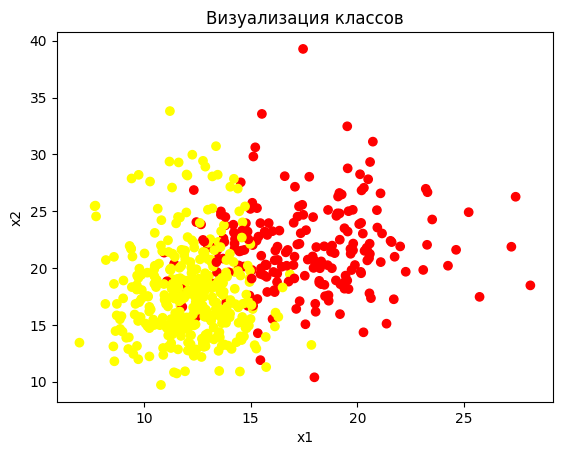

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

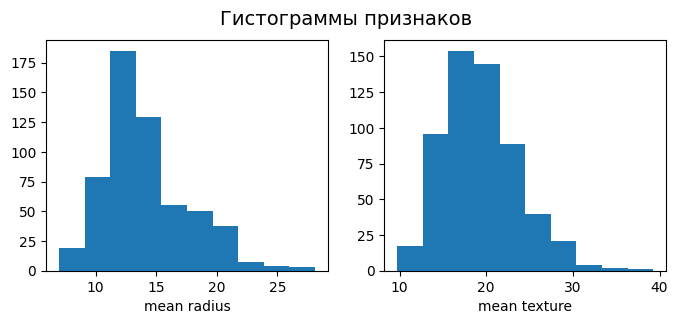

In [ ]:
plt.figure(figsize=(8, 3))
for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
gaussian_nb = GaussianNB()
gaussian_nb.fit(X, y)

GaussianNB()

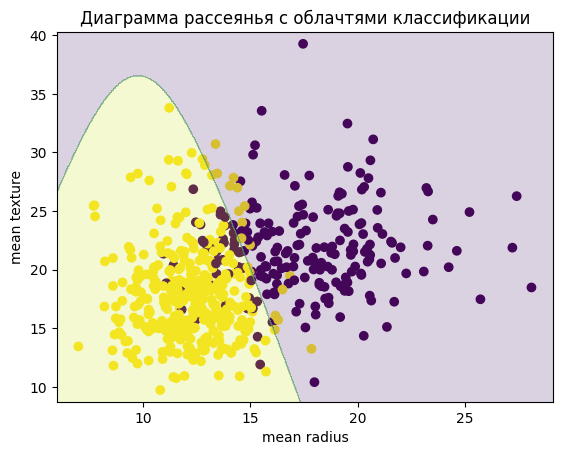

In [ ]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)
XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T

Z = gaussian_nb.predict(XX).reshape(X0_grid.shape)

plt.scatter(X[:, 0], X[:, 1], c=y,)
plt.contourf(X0_grid, X1_grid, Z, alpha = 0.2)

plt.title('Диаграмма рассеянья с облачтями классификации')
plt.xlabel('mean radius')
plt.ylabel('mean texture')
plt.show()

In [ ]:
y_pred = gaussian_nb.predict(X)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

In [ ]:
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[164  48]
 [ 17 340]]
Accuracy=  0.8857644991212654
F1_score=  0.912751677852349


In [ ]:
from sklearn.naive_bayes import MultinomialNB
miltinom_nb = MultinomialNB().fit(X, y)
y_pred = miltinom_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[ 36 176]
 [  7 350]]
Accuracy=  0.6783831282952548
F1_score=  0.7927519818799547


In [ ]:
from sklearn.naive_bayes import ComplementNB
compl_nb = ComplementNB().fit(X, y)
y_pred = compl_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[134  78]
 [136 221]]
Accuracy=  0.6239015817223199
F1_score=  0.6737804878048781


In [ ]:
from sklearn.naive_bayes import BernoulliNB
bern_nb = BernoulliNB().fit(X, y)
y_pred = bern_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[  0 212]
 [  0 357]]
Accuracy=  0.6274165202108963
F1_score=  0.7710583153347732


на всех данных

In [ ]:
X = data.data
y = data.target
X.shape, y.shape

((569, 30), (569,))

In [ ]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


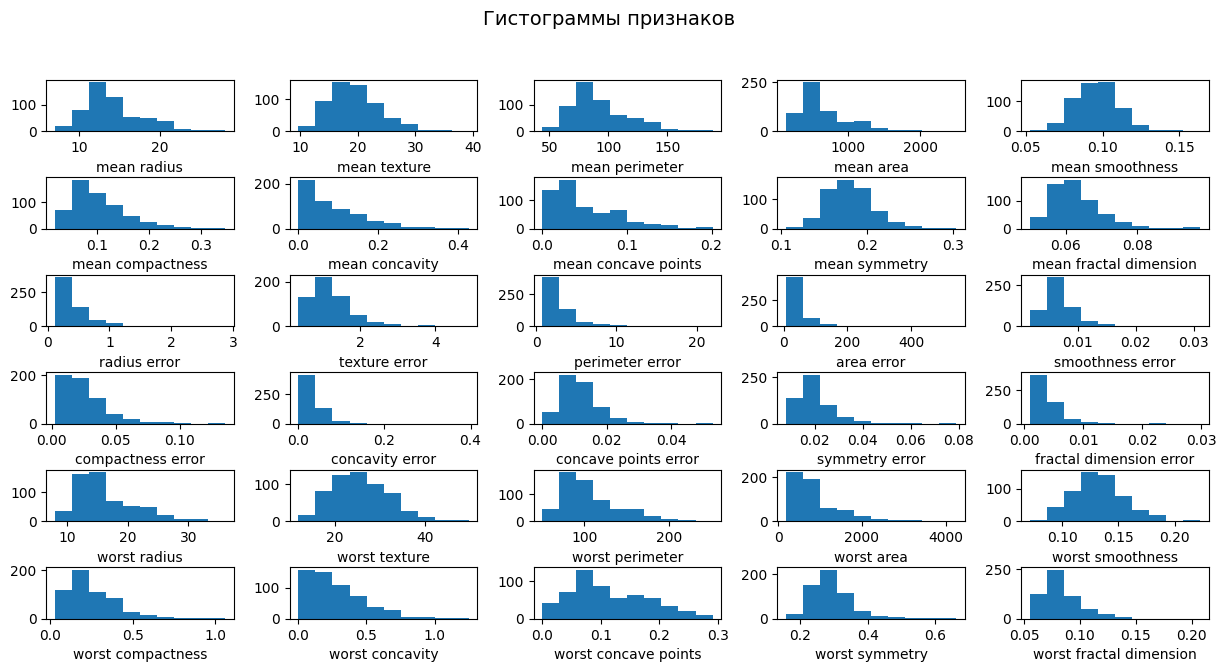

In [ ]:
f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X[:, i])

    plt.xlabel(data.feature_names[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

те, что не похожи на нормальное распределение, исключаем

In [ ]:
df = pd.DataFrame(data.data, columns = data.feature_names)
df = df.drop(['mean concavity','radius error',
              'perimeter error', 'area error',
              'compactness error', 'concavity error',
              'fractal dimension error', 'worst area',
              'worst concavity'],
             axis=1)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concave points,mean symmetry,mean fractal dimension,texture error,...,concave points error,symmetry error,worst radius,worst texture,worst perimeter,worst smoothness,worst compactness,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,...,0.01587,0.03003,25.38,17.33,184.60,0.1622,0.6656,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,...,0.01340,0.01389,24.99,23.41,158.80,0.1238,0.1866,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,...,0.02058,0.02250,23.57,25.53,152.50,0.1444,0.4245,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,...,0.01867,0.05963,14.91,26.50,98.87,0.2098,0.8663,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,...,0.01885,0.01756,22.54,16.67,152.20,0.1374,0.2050,0.1625,0.2364,0.07678


In [ ]:
X = df
y = data.target
X.shape, y.shape

((569, 21), (569,))

In [ ]:
gaussian_nb = GaussianNB().fit(X,y)
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[196  16]
 [ 15 342]]
Accuracy=  0.945518453427065
F1_score=  0.9566433566433566


1. На использованном в работе наборе данных примените другие вариации модели наивного Байеса - Мультономиальный, Бернулли, категориальные и комплементарный. Для каждой модели сделайте вывод о ее применимости.

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

X = data.data
y = data.target

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, CategoricalNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

models = [
    ('MultinomialNB', MultinomialNB()),
    ('BernoulliNB', BernoulliNB()),
    ('CategoricalNB', CategoricalNB()),
    ('ComplementNB', ComplementNB())
]
for name, model in models:
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(confusion_matrix(y, y_pred))
    print('F1_score= ', f1_score(y, y_pred))
    print(f'{name}: {accuracy}')

[[163  49]
 [ 10 347]]
F1_score=  0.9216467463479415
MultinomialNB: 0.8963093145869947
[[  0 212]
 [  0 357]]
F1_score=  0.7710583153347732
BernoulliNB: 0.6274165202108963
[[192  20]
 [  3 354]]
F1_score=  0.9685362517099864
CategoricalNB: 0.9595782073813708
[[163  49]
 [ 11 346]]
F1_score=  0.9202127659574468
ComplementNB: 0.8945518453427065


2. Загрузите набор данных о выживших на титанике, прилагающийся к этой работе. Повторите на нем моделирование из методических указаний. Попробуйте разные варианты байесовского классификатора в зависимости от форм расрпеделния эмпирических данных.

In [ ]:
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,0,0,1
1,2,1,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1
3,4,1,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,0,35.0,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000,0,0,1
887,888,1,1,1,19.0,0,0,30.0000,0,0,1
888,889,0,3,1,29.0,1,2,23.4500,0,0,1
889,890,1,1,0,26.0,0,0,30.0000,1,0,0


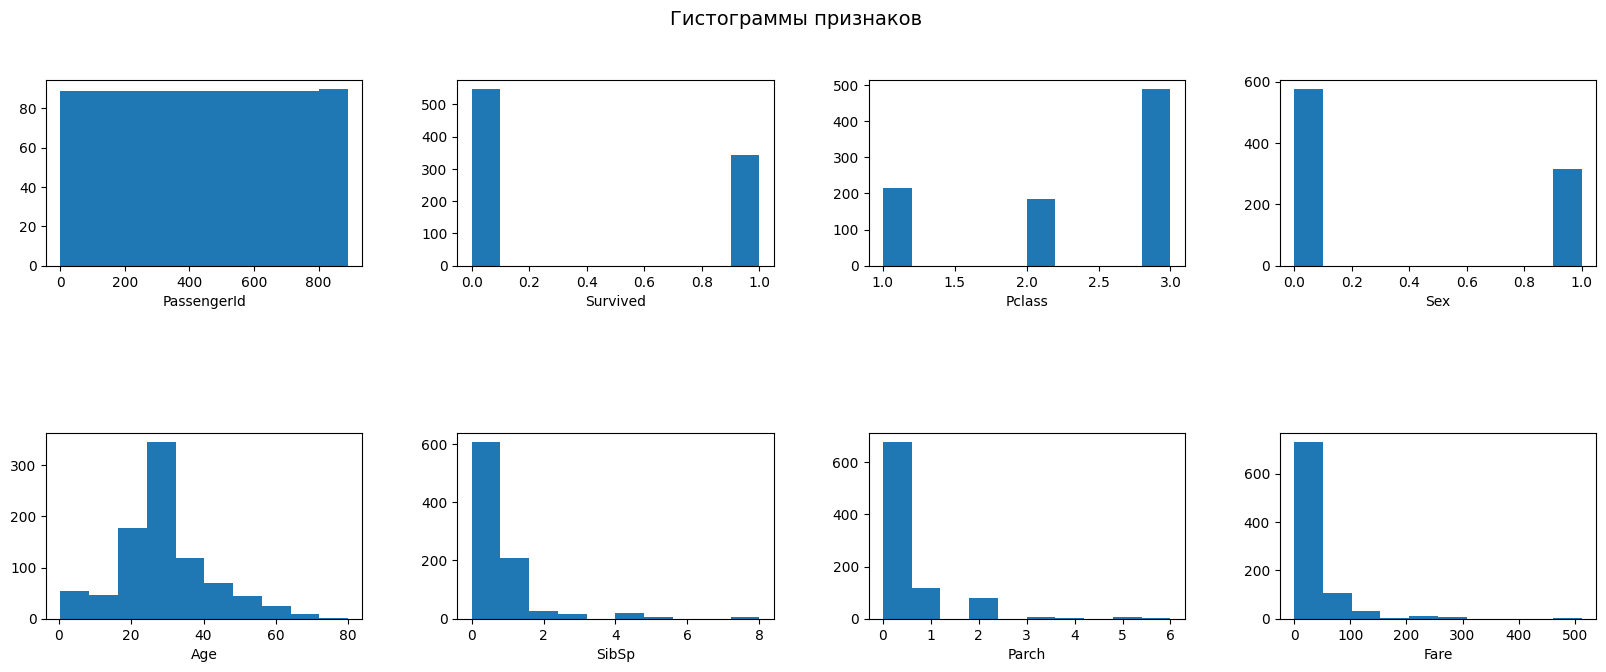

In [ ]:
X = df.iloc[:,:7]
y = df.iloc[:,-3:]

f = plt.figure(figsize=(20, 7))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.hist(df.iloc[:, i].values)
    plt.xlabel(df.columns[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

In [ ]:
df = df.drop(['PassengerId',	'Survived',	'Pclass',	'Sex'], axis=1)
y = y.values
x = df.iloc[:,:4].values

In [ ]:
y_target = np.dot(y , np.array([3, 2, 1]))

models = [
    ('MultinomialNB', MultinomialNB()),
    ('BernoulliNB', BernoulliNB()),
    ('CategoricalNB', CategoricalNB()),
    ('ComplementNB', ComplementNB()),
    (' GaussianNB', GaussianNB())
]

for name, model in models:
    model.fit(x, y_target)
    y_pred = model.predict(x)
    accuracy = accuracy_score(y_target, y_pred)
    print(f'{name}: {accuracy:.4f}')

MultinomialNB: 0.3749
BernoulliNB: 0.7250
CategoricalNB: 0.7834
ComplementNB: 0.6251
 GaussianNB: 0.7306


3. Загрузите набор данных о Титанике с сайта Kaggle. Обратите внимание на обилие категориальных переменных. Примените на нем наивный байесовский классификатор.

In [ ]:
df = pd.read_csv('tested.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
data = df.drop(['PassengerId', 'Sex','Name','Cabin','Embarked'], axis=1).dropna()
data

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
0,0,3,34.5,0,0,330911,7.8292
1,1,3,47.0,1,0,363272,7.0000
2,0,2,62.0,0,0,240276,9.6875
3,0,3,27.0,0,0,315154,8.6625
4,1,3,22.0,1,1,3101298,12.2875
...,...,...,...,...,...,...,...
409,1,3,3.0,1,1,SOTON/O.Q. 3101315,13.7750
411,1,1,37.0,1,0,19928,90.0000
412,1,3,28.0,0,0,347086,7.7750
414,1,1,39.0,0,0,PC 17758,108.9000


In [ ]:
X = data.iloc[:, 1:]
y = data.iloc[:, 1].values
models = [
    ('MultinomialNB', MultinomialNB()),
    ('BernoulliNB', BernoulliNB()),
    ('CategoricalNB', CategoricalNB()),
    ('ComplementNB', ComplementNB()),
    (' GaussianNB', GaussianNB())
]

for name, model in models:
    model.fit(x, y_target)
    y_pred = model.predict(x)
    accuracy = accuracy_score(y_target, y_pred)
    print(f'{name}: {accuracy:.4f}')

MultinomialNB: 0.3749
BernoulliNB: 0.7250
CategoricalNB: 0.7834
ComplementNB: 0.6251
 GaussianNB: 0.7306
